In [100]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image_path = "./assets/tray3.jpg"

In [102]:
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Nie można znaleźć pliku: {image_path}")

# Kopia obrazu dla rysowania i konwersja do RGB (dla Matplotliba)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konwersja do skali szarości i rozmycie w celu redukcji szumów
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 1.5)

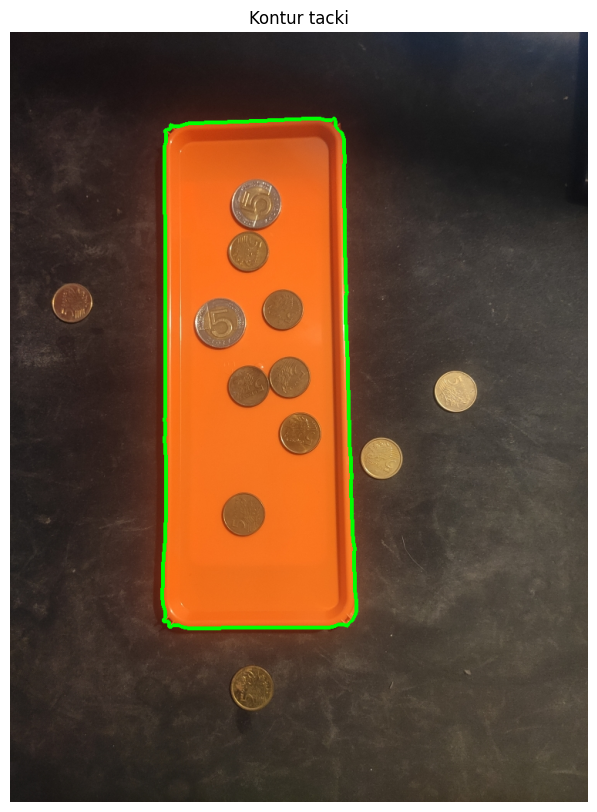

In [ ]:
#WYZNACZANIE KONTURU TACKI
#Zastosowanie detekcji krawędzi Canny
edges = cv2.Canny(blurred, 50, 145)

# Operacje morfologiczne, aby połączyć krawędzie tacki
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# Znalezienie konturów
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_with_tray_contour = img_rgb.copy()

# Zakładamy, że największy znaleziony kontur to nasza tacka
if contours:
    tray_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(img_with_tray_contour, [tray_contour], -1, (0, 255, 0), 3) # Zielona linia dla tacki
else:
    raise ValueError("Nie znaleziono konturu tacki")

plt.figure(figsize=(12, 10))
plt.imshow(img_with_tray_contour)
plt.title("Kontur tacki")
plt.axis("off")
plt.show()

In [104]:
#Obaszar tacki
tray_area = cv2.contourArea(tray_contour)
print(f"Obszar tacki: {tray_area:.0f} pikseli kwadratowych")

Obszar tacki: 156254 pikseli kwadratowych


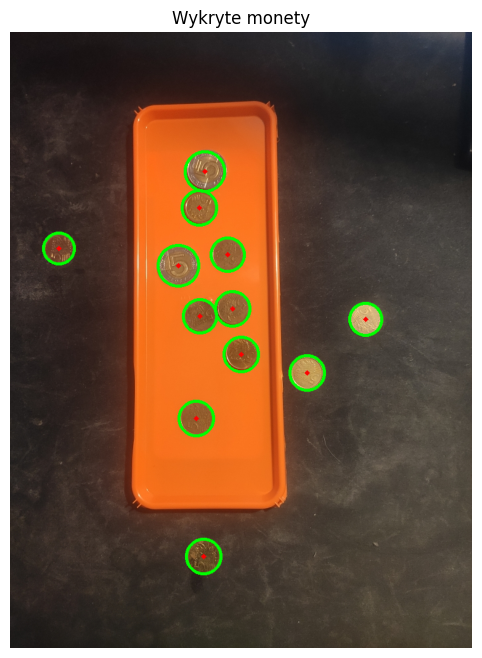

In [105]:
#Znajdowanie monet za pomocą HoughCircles
img_with_coin_countours = img_rgb.copy()

circles = cv2.HoughCircles(
    blurred, 
    cv2.HOUGH_GRADIENT, 
    dp=1.2, 
    minDist=40,       # Minimalny dystans pomiędzy środkami monet
    param1=50,        # Czułość Canny używana przez Hough
    param2=50,        # Próg dla akceptacji środka monety (im niższy, tym więcej fałszywych okręgów)
    minRadius=20,     # Minimalny promień monety
    maxRadius=80      # Maksymalny promień monety
)

if circles is not None:
    # 2. Zaokrąglenie współrzędnych do liczb całkowitych (piksele nie mogą być ułamkami)
    circles = np.uint16(np.around(circles))
    
    # 3. Pętla przechodząca przez każdą znalezioną monetę
    for i in circles[0, :]:
        center = (i[0], i[1]) # Współrzędne środka (x, y)
        radius = i[2]         # Promień okręgu
        
        # Rysowanie obrysu monety (tutaj na zielono: R=0, G=255, B=0)
        # Argumenty: obraz, środek, promień, kolor, grubość linii
        cv2.circle(img_with_coin_countours, center, radius, (0, 255, 0), 3)
        
        # Rysowanie punktu na samym środku monety (tutaj na czerwono: R=255, G=0, B=0)
        cv2.circle(img_with_coin_countours, center, 2, (255, 0, 0), 3)

else:
    print("Nie wykryto żadnych monet przy obecnych parametrach!")

plt.figure(figsize=(10, 8))
plt.imshow(img_with_coin_countours)
plt.title("Wykryte monety")
plt.axis("off") 
plt.show()

In [106]:
# Zmienne do zliczania i kwot [Zadanie 4 i 5]
large_on_tray = 0
small_on_tray = 0
large_off_tray = 0
small_off_tray = 0

# Konfiguracja nominałów (przykład: duża=5zł, mała=1zł) - do podmiany po analizie zdjęć!
VAL_LARGE = 5.0 
VAL_SMALL = 1.0 

THRESHOLD_RADIUS = 30

In [107]:
img_for_counting = img_rgb.copy()

# Sprawdzamy, czy w ogóle wykryto jakieś monety we wcześniejszej komórce
if circles is not None:
    for i in circles[0, :]:
        center = (int(i[0]), int(i[1])) # (x, y)
        radius = i[2]
        
    
        
        # 3. Sprawdzenie czy moneta jest na tacce
        # cv2.pointPolygonTest zwraca +1 (w środku), 0 (na krawędzi), -1 (na zewnątrz)
        # Zastąp 'tray_contour' nazwą swojej zmiennej z konturem tacki!
        is_inside = cv2.pointPolygonTest(tray_contour, center, measureDist=False) >= 0
        
        # 4. Sprawdzenie czy moneta jest duża czy mała
        is_large = radius > THRESHOLD_RADIUS
        
        # 5. Przypisywanie do odpowiednich kategorii
        if is_inside:
            if is_large:
                large_on_tray += 1
            else:
                small_on_tray += 1
        else:
            if is_large:
                large_off_tray += 1
            else:
                small_off_tray += 1

    # 6. Obliczenie łącznych kwot [Zadanie 5]
    money_on_tray = (large_on_tray * VAL_LARGE) + (small_on_tray * VAL_SMALL)
    money_off_tray = (large_off_tray * VAL_LARGE) + (small_off_tray * VAL_SMALL)

    # 7. Wyświetlenie wyników
    print("-" * 30)
    print("PODSUMOWANIE MONET [Zadanie 4]:")
    print(f"Na tacce   -> Duże: {large_on_tray}, Małe: {small_on_tray}")
    print(f"Poza tacką -> Duże: {large_off_tray}, Małe: {small_off_tray}")
    print("-" * 30)
    print("PODSUMOWANIE KWOT [Zadanie 5]:")
    print(f"Kwota na tacce   : {money_on_tray} PLN")
    print(f"Kwota poza tacką : {money_off_tray} PLN")
    print("-" * 30)

else:
    print("Zmienna 'circles' jest pusta lub nie istnieje. Uruchom najpierw komórkę z HoughCircles.")

------------------------------
PODSUMOWANIE MONET [Zadanie 4]:
Na tacce   -> Duże: 2, Małe: 6
Poza tacką -> Duże: 0, Małe: 4
------------------------------
PODSUMOWANIE KWOT [Zadanie 5]:
Kwota na tacce   : 16.0 PLN
Kwota poza tacką : 4.0 PLN
------------------------------
